# Olist End-to-End Business Data Analytics
## Notebook 02 — Exploratory Data Analysis & Business Analysis

The goal is to understand the main business patterns behind seller acquisition, marketplace performance and customer satisfaction before moving to SQL and final business recommendations.

## Main business questions

1. Which acquisition channels bring sellers with stronger commercial performance after conversion?
2. How reliable is delivery performance, and are there meaningful regional differences?
3. Which factors are most associated with lower customer satisfaction: delivery performance, product category, or price?
4. Do sellers acquired through different channels show different commercial performance, operational performance, and customer satisfaction?

## Analysis scope

The analysis focuses on three business areas:

- **Commercial performance:** GMV as the main metric, supported by number of orders and AOV.
- **Delivery performance:** average delivery time and late delivery rate.
- **Customer satisfaction:** average review score.

Each business question will use only the datasets, variables and metrics needed to answer it.

A key limitation is that only **380 of the 842 Marketing-acquired sellers** are observed in the available E-Commerce data. Therefore, analyses connecting acquisition channels with downstream seller performance apply only to this observable subset.

## Research hypotheses

### Q1 — Seller acquisition and commercial performance

**Research question:**  
Which acquisition channels bring sellers with stronger commercial performance after conversion?

**H0:** Mean GMV does not differ significantly across acquisition channels.

**H1:** Mean GMV differs significantly across acquisition channels.

**Primary metric:** GMV  
**Supporting metrics:** Number of orders and AOV


### Q2 — Marketplace delivery performance

**Research question:**  
How reliable is delivery performance, and are there meaningful regional differences?

**H0:** Mean delivery time does not differ significantly across regions.

**H1:** Mean delivery time differs significantly across regions.

**Primary metric:** Average delivery time  
**Supporting metric:** Late delivery rate

Delivery performance will be evaluated through average delivery time, late delivery rate and delivery-time variability.


### Q3 — Customer satisfaction

**Research question:**  
Which factors are most associated with lower customer satisfaction: delivery performance, product category or price?

**H0:** Delivery performance, product category and price are not significantly associated with review scores.

**H1:** At least one of these factors is significantly associated with review scores.

**Primary metric:** Average review score

### Q4 — Acquisition, performance and satisfaction

**Research question:**  
Do sellers acquired through different channels show different commercial performance, operational performance and customer satisfaction?

**Purpose:** Integrate the previous findings to evaluate whether acquisition channel is associated not only with commercial outcomes, but also with downstream operational performance and customer satisfaction.

**H0:** Acquisition channel is not significantly associated with differences in seller commercial performance, operational performance or customer satisfaction.

**H1:** At least one seller performance dimension differs significantly across acquisition channels.

In [1]:
# Import libraries 

import pandas as pd
import numpy as np

# for visualizations
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Path to cleaned datasets exported from Notebook 1

PROCESSED_PATH = "../data/processed"

In [3]:
# Load cleaned E-Commerce datasets

customers = pd.read_csv(f"{PROCESSED_PATH}/customers_clean.csv")
orders = pd.read_csv(f"{PROCESSED_PATH}/orders_clean.csv")
order_items = pd.read_csv(f"{PROCESSED_PATH}/order_items_clean.csv")
payments = pd.read_csv(f"{PROCESSED_PATH}/payments_clean.csv")
reviews = pd.read_csv(f"{PROCESSED_PATH}/reviews_clean.csv")
products = pd.read_csv(f"{PROCESSED_PATH}/products_clean.csv")
sellers = pd.read_csv(f"{PROCESSED_PATH}/sellers_clean.csv")
geolocation = pd.read_csv(f"{PROCESSED_PATH}/geolocation_clean.csv")
category_translation = pd.read_csv(f"{PROCESSED_PATH}/category_translation_clean.csv")

In [4]:
# Load cleaned Marketing Funnel datasets

mql = pd.read_csv(f"{PROCESSED_PATH}/mql_clean.csv")
closed_deals = pd.read_csv(f"{PROCESSED_PATH}/closed_deals_clean.csv")

In [5]:
# Load ZIP-level geolocation reference created in Notebook 1

geolocation_zip = pd.read_csv(f"{PROCESSED_PATH}/geolocation_zip_reference.csv")

In [6]:
print("E-COMMERCE DATASETS")
print("customers:", customers.shape)
print("orders:", orders.shape)
print("order_items:", order_items.shape)
print("payments:", payments.shape)
print("reviews:", reviews.shape)
print("products:", products.shape)
print("sellers:", sellers.shape)
print("geolocation:", geolocation.shape) 
print("category_translation:", category_translation.shape) 

print("\nMARKETING FUNNEL DATASETS")
print("mql:", mql.shape)
print("closed_deals:", closed_deals.shape) 

print("\nZIP-level geolocation ")
print("geolocation_zip:", geolocation_zip.shape)

E-COMMERCE DATASETS
customers: (99441, 5)
orders: (99441, 8)
order_items: (112650, 7)
payments: (103886, 5)
reviews: (99224, 5)
products: (32951, 9)
sellers: (3095, 4)
geolocation: (738332, 5)
category_translation: (71, 2)

MARKETING FUNNEL DATASETS
mql: (8000, 4)
closed_deals: (842, 14)

ZIP-level geolocation 
geolocation_zip: (19015, 3)


### Data loaded

The cleaned datasets exported from Notebook 01 were loaded successfully.

The analysis will keep the E-Commerce and Marketing Funnel datasets separate until a specific business question requires connecting them. The ZIP-level geolocation reference will be used only when geographic coordinates are needed.

# 1. Prepare the analytical variables

## Business metrics dictionary

Before starting the EDA, the main business metrics used to answer the project questions are defined below.

The analysis focuses on three areas: **commercial performance, delivery performance, and customer satisfaction**.

| Area | Metric | Definition | Calculation |
|---|---|---|---|
| Commercial performance | **GMV** | Gross Merchandise Value. Total value of products sold by a seller in the marketplace. | Sum of `price` |
| Commercial performance | **Number of orders** | Number of unique orders in which a seller participated. | Unique count of `order_id` |
| Commercial performance | **AOV** | Average value generated by the seller per order. | GMV / Number of orders |
| Delivery performance | **Average delivery time** | Average number of days between purchase and delivery to the customer. | Delivery date - Purchase date |
| Delivery performance | **Late delivery rate** | Percentage of delivered orders that arrived after the estimated delivery date. | Late delivered orders / Delivered orders |
| Customer satisfaction | **Average review score** | Average customer review score associated with the seller's orders. | Mean `review_score` |

These metrics will be analyzed using the relevant business dimensions, such as **acquisition channel, customer region, product category, and price**, depending on the business question.

### 1.1. Build the seller commercial performance dataset

To answer the seller acquisition questions, we first create a seller-level dataset containing the commercial performance metrics needed for the analysis.

Each row represents one seller, with **GMV, number of orders and AOV** calculated from `order_items`.

This dataset will later be connected to the Marketing Funnel through `seller_id` to compare commercial performance across acquisition channels.

### Commercial performance

In [7]:
seller_commercial = order_items.groupby("seller_id").agg(gmv=("price", "sum"), number_of_orders=("order_id", "nunique")).reset_index() 
seller_commercial.head()

,seller_id,gmv,number_of_orders
0,0015a82c2db000af6aaaf3ae2ecb0532,2685.00,3
1,001cca7ae9ae17fb1caed9dfb1094831,25080.03,200
2,001e6ad469a905060d959994f1b41e4f,250.00,1
3,002100f778ceb8431b7a1020ff7ab48f,1234.50,51
4,003554e2dce176b5555353e4f3555ac8,120.00,1


In [8]:
#AOV at the seller level: GMV / number of unique orders in which they participated.

seller_commercial["aov"] = seller_commercial["gmv"] / seller_commercial["number_of_orders"]
seller_commercial.head()

# Note: This is the value of what that seller sold within the order, not the total value of the customer's order (which may include other sellers).

,seller_id,gmv,number_of_orders,aov
0,0015a82c2db000af6aaaf3ae2ecb0532,2685.00,3,895.000000
1,001cca7ae9ae17fb1caed9dfb1094831,25080.03,200,125.400150
2,001e6ad469a905060d959994f1b41e4f,250.00,1,250.000000
3,002100f778ceb8431b7a1020ff7ab48f,1234.50,51,24.205882
4,003554e2dce176b5555353e4f3555ac8,120.00,1,120.000000


In [9]:
# Add acquisition channel to converted sellers

seller_acquisition = closed_deals[["seller_id", "mql_id"]].merge(mql[["mql_id", "origin"]],on="mql_id",how="left")

seller_acquisition.head()

,seller_id,mql_id,origin
0,2c43fb513632d29b3b58df74816f1b06,5420aad7fec3549a85876ba1c529bd84,organic_search
1,bbb7d7893a450660432ea6652310ebb7,a555fb36b9368110ede0f043dfc3b9a0,referral
2,612170e34b97004b3ba37eae81836b4c,327174d3648a2d047e8940d7d15204ca,organic_search
3,21e1781e36faf92725dde4730a88ca0f,f5fee8f7da74f4887f5bcae2bafb6dd6,paid_search
4,ed8cb7b190ceb6067227478e48cf8dde,ffe640179b554e295c167a2f6be528e0,unknown


## 2. Q1 — Seller acquisition and commercial performance

This section investigates whether sellers acquired through different Marketing Funnel channels show different commercial performance after conversion.

GMV is used as the primary commercial performance metric, while number of orders and AOV are used as supporting metrics.

The analysis first examines the acquisition-channel composition and overall GMV distribution before comparing seller performance across channels.

### 2.1 Build the Q1 analytical dataset

In [10]:
# Connect acquisition channel with seller commercial performance

seller_acquisition_performance = seller_acquisition.merge(seller_commercial, on="seller_id",how="inner")

seller_acquisition_performance.head()

,seller_id,mql_id,origin,gmv,number_of_orders,aov
0,2c43fb513632d29b3b58df74816f1b06,5420aad7fec3549a85876ba1c529bd84,organic_search,858.00,3,286.000000
1,612170e34b97004b3ba37eae81836b4c,327174d3648a2d047e8940d7d15204ca,organic_search,23065.02,107,215.560935
2,ed8cb7b190ceb6067227478e48cf8dde,ffe640179b554e295c167a2f6be528e0,unknown,573.50,15,38.233333
3,1c742ac33582852aaf3bcfbf5893abcf,b94fba7670eeb44dce2a0d8eb790e9f5,organic_search,97.90,1,97.900000
4,44ed138eca6214d572ce1d813fb0049b,b02c89251106e1fdd9d92744be9f94f2,unknown,129.79,2,64.895000


In [11]:
print("Sellers with acquisition and commercial performance:", seller_acquisition_performance["seller_id"].nunique())

print("Dataset shape:", seller_acquisition_performance.shape)

Sellers with acquisition and commercial performance: 380
Dataset shape: (380, 6)


### Analytical dataset check

The acquisition-performance dataset contains the Marketing-acquired sellers for whom commercial activity can be observed in the available E-Commerce data.

This matches the Marketing–E-Commerce overlap identified during the data validation performed in Notebook 01.

### 2.2 Acquisition channel distribution

In [12]:
seller_acquisition_performance["origin"].value_counts()

origin
organic_search    113
paid_search       101
unknown            81
direct_traffic     31
social             31
referral            9
email               6
missing             4
other               2
display             2
Name: count, dtype: int64

In [13]:
# Acquisition channel distribution (%)

seller_acquisition_performance["origin"].value_counts(normalize=True) * 100

origin
organic_search    29.736842
paid_search       26.578947
unknown           21.315789
direct_traffic     8.157895
social             8.157895
referral           2.368421
email              1.578947
missing            1.052632
other              0.526316
display            0.526316
Name: proportion, dtype: float64

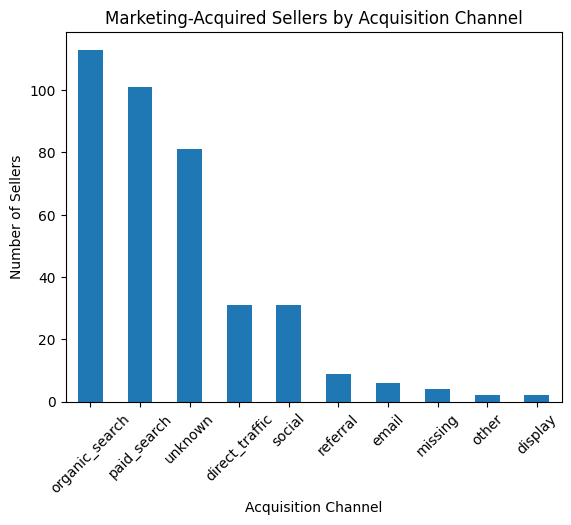

In [14]:
# Visualize acquisition channel distribution

seller_acquisition_performance["origin"].value_counts().plot(kind="bar")

plt.title("Marketing-Acquired Sellers by Acquisition Channel")
plt.xlabel("Acquisition Channel")
plt.ylabel("Number of Sellers")
plt.xticks(rotation=45)
plt.show()

### Findings

The observable Marketing-acquired sellers are not evenly distributed across acquisition channels.

`organic_search` and `paid_search` are the two largest identifiable acquisition channels, while a relevant share of sellers has an `unknown` acquisition origin.

Several other acquisition channels contain substantially fewer observations. These differences in sample size should be considered when interpreting channel-level performance.

The `unknown` group will remain visible during the exploratory analysis, but it cannot be interpreted as a specific acquisition strategy.

### 2.3 GMV distribution

GMV is the primary metric used to measure seller commercial performance.

Before comparing acquisition channels, its overall distribution is examined to understand typical seller performance and determine whether extreme values may strongly influence the mean.

In [15]:
# Summary statistics for seller GMV

seller_acquisition_performance["gmv"].describe()

count       380.000000
mean       1781.188105
std        6800.937058
min          18.900000
25%         179.650000
50%         547.405000
75%        1286.000000
max      113628.970000
Name: gmv, dtype: float64

In [16]:
# Compare mean and median GMV

print("Mean GMV:", seller_acquisition_performance["gmv"].mean())

print("Median GMV:", seller_acquisition_performance["gmv"].median())

Mean GMV: 1781.188105263158
Median GMV: 547.405


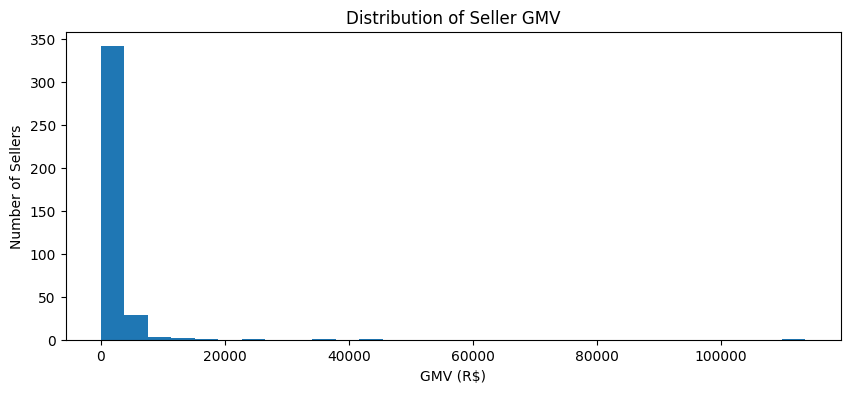

In [17]:
# Visualize GMV distribution

plt.figure(figsize=(10, 4))

plt.hist(seller_acquisition_performance["gmv"],bins=30)

plt.title("Distribution of Seller GMV")
plt.xlabel("GMV (R$)")
plt.ylabel("Number of Sellers")
plt.show()

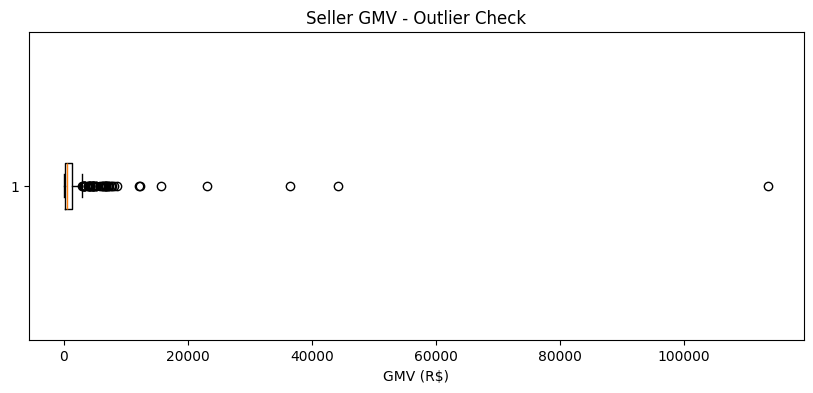

In [18]:
# Visualize GMV outliers

plt.figure(figsize=(10, 4))

plt.boxplot(seller_acquisition_performance["gmv"], vert=False)

plt.title("Seller GMV - Outlier Check")
plt.xlabel("GMV (R$)")
plt.show()

### 2.4 GMV outlier investigation

In [19]:
# Identify potential GMV outliers using IQR

Q1 = seller_acquisition_performance["gmv"].quantile(0.25)
Q3 = seller_acquisition_performance["gmv"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Upper bound:", upper_bound)

Q1: 179.65
Q3: 1286.0
IQR: 1106.35
Upper bound: 2945.5249999999996


In [20]:
# Inspect potential GMV outliers

gmv_outliers = seller_acquisition_performance[seller_acquisition_performance["gmv"] > upper_bound]

print("Number of potential outliers:", len(gmv_outliers))

gmv_outliers.sort_values("gmv", ascending=False).head(10)

Number of potential outliers: 46


,seller_id,mql_id,origin,gmv,number_of_orders,aov
12,7d13fca15225358621be4086e1eb0964,0b97be8b4b408a3a0780a32e0a143a7f,unknown,113628.97,565,201.113221
279,ba90964cff9b9e0e6f32b23b82465f7b,8257329475414b1eaf3dc731440e01a7,organic_search,44212.50,38,1163.486842
273,c70c1b0d8ca86052f45a432a38b73958,7b6ad2297d3beb569ddf3ee1ce22ffa8,paid_search,36537.37,261,139.989923
1,612170e34b97004b3ba37eae81836b4c,327174d3648a2d047e8940d7d15204ca,organic_search,23065.02,107,215.560935
36,6061155addc1e54b4cfb51c1c2a32ad8,8d6be534a8bdd08e11efe57c6ce3dd21,organic_search,15633.40,28,558.335714
316,c510bc1718f0f2961eaa42a23330681a,7bf1f5c2051159d32a588de7a73c8edf,unknown,12251.00,13,942.384615
14,70c27847eca8195c983ed7e798c56743,fc4166d1b1e192f650ee2d807b54c943,social,12077.52,77,156.850909
168,db2956745b3a8e9f3785c99f34b5d25e,e84d3444422cda735543114cf5df6b95,unknown,8599.00,47,182.957447
170,4bfc7a4a1cf8d4d2121c27422d9e50b5,860e39bc33e7c4ca4c26ec67979cc290,paid_search,8124.40,26,312.476923
363,8476243f92442881ddd5b578975cf115,1b9d7ffccca875a9079e3b57c24a3113,unknown,7838.00,12,653.166667


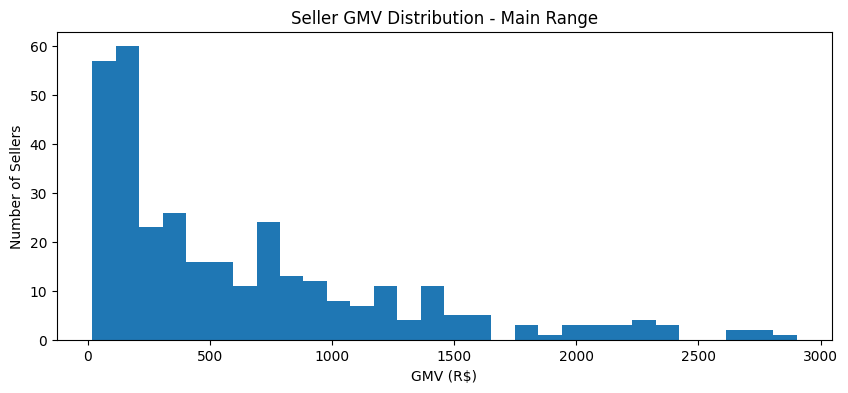

In [21]:
# Visualize the main GMV distribution below the IQR upper bound

gmv_main_distribution = seller_acquisition_performance[seller_acquisition_performance["gmv"] <= upper_bound]
plt.figure(figsize=(10, 4))
plt.hist(gmv_main_distribution["gmv"], bins=30)

plt.title("Seller GMV Distribution - Main Range")
plt.xlabel("GMV (R$)")
plt.ylabel("Number of Sellers")
plt.show()

#### GMV distribution findings

Seller GMV is strongly right-skewed. The mean GMV (1,781.19 BRL) is considerably higher than the median (547.41 BRL), indicating that a relatively small number of high-performing sellers are pulling the average upward.

Using the IQR method, 46 of the 380 sellers (12.1%) were identified as potential GMV outliers, with values above 2,945.52 BRL.

However, these observations are not automatically treated as errors. Several of the highest-GMV sellers also have a high number of orders, suggesting that at least part of these extreme values may represent genuinely high-performing sellers.

For this reason, potential GMV outliers are retained in the analysis. High GMV values may represent genuine high-performing sellers, and removing them could eliminate meaningful business information. Their influence on mean-based comparisons will therefore be considered when interpreting the results.

### 2.5 Commercial performance by acquisition channel

We now compare seller commercial performance across acquisition channels.

GMV remains the primary performance metric, while number of orders and AOV provide additional context.

Because GMV is strongly right-skewed and channel sample sizes vary considerably, both mean and median GMV are considered during the descriptive analysis.

In [24]:
# GMV performance by acquisition channel

gmv_by_channel = seller_acquisition_performance.groupby("origin")["gmv"].agg(["count", "mean", "median"]).sort_values("median", ascending=False)

gmv_by_channel

,count,mean,median
origin,,,
other,2,3444.325000,3444.325
referral,9,1987.461111,1368.500
social,31,1402.515806,722.200
organic_search,113,1832.065929,634.200
unknown,81,2638.798765,573.500
paid_search,101,1537.396535,512.000
display,2,461.500000,461.500
direct_traffic,31,706.577419,399.000
email,6,1414.165000,338.200


### 2.6 Focus on the two largest known acquisition channels

`organic_search` and `paid_search` are the two largest identifiable acquisition channels.

Because they provide the largest and most comparable samples, they are examined more closely to understand descriptive differences in seller commercial performance.

This comparison complements the broader channel-level analysis rather than replacing it.


In [28]:
# Two largest known acquisition channels

main_channels = seller_acquisition_performance[seller_acquisition_performance["origin"].isin(["organic_search", "paid_search"])]

main_channels.shape

(214, 6)

In [29]:
# GMV comparison between organic and paid search

main_channels.groupby("origin")["gmv"].agg(["count", "mean", "median"])

,count,mean,median
origin,,,
organic_search,113,1832.065929,634.2
paid_search,101,1537.396535,512.0


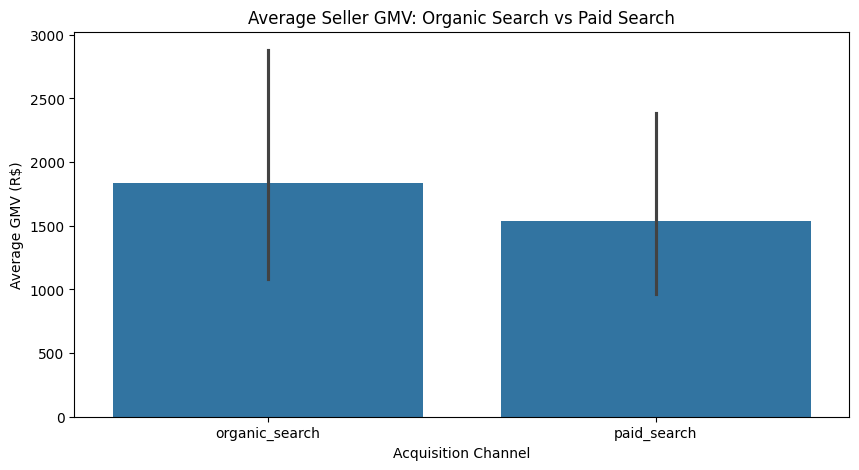

In [30]:
# Compare mean GMV between organic and paid search

plt.figure(figsize=(10, 5))

sns.barplot(data=main_channels, x="origin",y="gmv")

plt.title("Average Seller GMV: Organic Search vs Paid Search")
plt.xlabel("Acquisition Channel")
plt.ylabel("Average GMV (R$)")
plt.show()

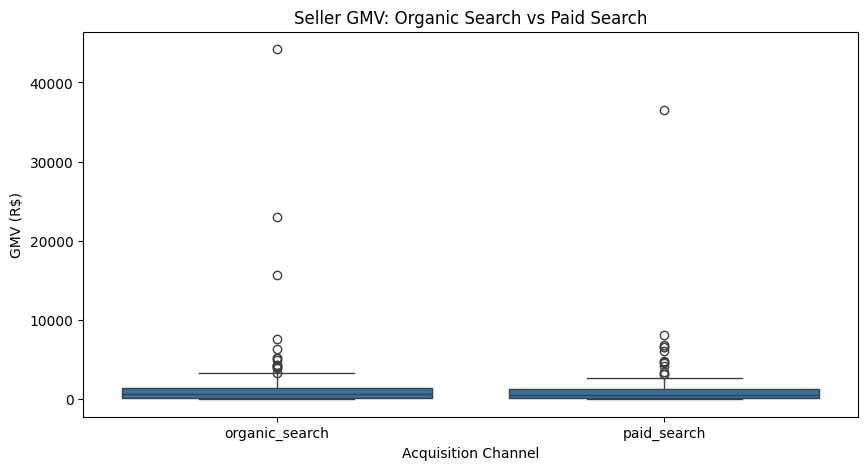

In [31]:
# Compare GMV distributions

plt.figure(figsize=(10, 5))

sns.boxplot(data=main_channels, x="origin",y="gmv")

plt.title("Seller GMV: Organic Search vs Paid Search")
plt.xlabel("Acquisition Channel")
plt.ylabel("GMV (R$)")
plt.show()

In [32]:
# Supporting commercial metrics

main_channels.groupby("origin")[["number_of_orders", "aov"]].agg(["mean", "median"])

number_of_orders                aov            
                           mean median        mean      median
origin                                                        
organic_search        10.690265    5.0  201.197235  105.533333
paid_search           12.346535    4.0  189.586840  104.750000

### Organic Search vs Paid Search — Initial findings

The descriptive comparison shows differences in GMV between the two largest known acquisition channels.

Number of orders and AOV provide additional context for understanding these differences rather than being treated as separate performance outcomes.

However, descriptive differences alone cannot determine whether acquisition channel is statistically associated with seller commercial performance.

Hypothesis testing is therefore used to evaluate whether the observed GMV differences are statistically significant.

### 2.7 Hypothesis testing — Acquisition channel and GMV

The exploratory analysis suggests differences in seller GMV across acquisition channels. Hypothesis testing will determine whether the observed differences among the main acquisition channels are statistically significant.

The formal comparison focuses on the four largest known acquisition channels with sufficient observations: `organic_search`, `paid_search`, `direct_traffic`, and `social`.

**H0:** Mean seller GMV is equal across the four main acquisition channels.

**H1:** At least one of the four main acquisition channels has a different mean seller GMV.

**Significance level:** α = 0.05

`unknown` and `missing` are excluded because they do not represent identifiable acquisition strategies. Smaller known channels remain visible in the exploratory analysis but are not included in the formal comparison because of their limited sample sizes.

In [33]:
# Main acquisition channels included in hypothesis testing

test_channels = seller_acquisition_performance[seller_acquisition_performance["origin"].isin(["organic_search", "paid_search", "direct_traffic", "social"])].copy()

test_channels["origin"].value_counts()


origin
organic_search    113
paid_search       101
direct_traffic     31
social             31
Name: count, dtype: int64

In [34]:
# GMV samples for hypothesis testing

organic_gmv = test_channels[test_channels["origin"] == "organic_search"]["gmv"]

paid_gmv = test_channels[test_channels["origin"] == "paid_search"]["gmv"]

direct_gmv = test_channels[test_channels["origin"] == "direct_traffic"]["gmv"]

social_gmv = test_channels[test_channels["origin"] == "social"]["gmv"]

print("Organic search:", len(organic_gmv))
print("Paid search:", len(paid_gmv))
print("Direct traffic:", len(direct_gmv))
print("Social:", len(social_gmv))

Organic search: 113
Paid search: 101
Direct traffic: 31
Social: 31


### 2.8 Normality check

Before running ANOVA, the GMV distribution is checked for the four channels included in the formal comparison.

The Shapiro-Wilk test is used because it was covered in the bootcamp and provides a statistical check of normality.

In [36]:
# Import statistical functions for hypothesis testing
import scipy.stats as st

In [37]:
# Shapiro-Wilk normality test

for channel in test_channels["origin"].unique():

    channel_gmv = test_channels[
        test_channels["origin"] == channel]["gmv"]

    result = st.shapiro(channel_gmv)

    print(channel, "- n:", len(channel_gmv), "- p-value:", result.pvalue)

organic_search - n: 113 - p-value: 1.9869015966431024e-20
paid_search - n: 101 - p-value: 2.658258388265811e-19
direct_traffic - n: 31 - p-value: 5.0628908810178605e-09
social - n: 31 - p-value: 6.616837246664683e-09


### Normality check — interpretation

The Shapiro-Wilk test indicates that GMV is not normally distributed across the four acquisition channels included in the formal comparison (p < 0.05).

This result is consistent with the strong right-skew and extreme GMV values already observed during the exploratory analysis.

The normality assumption should therefore be considered when interpreting the ANOVA results.

### 2.9 ANOVA

In [38]:
# ANOVA across the four main acquisition channels

anova_stat, anova_p_value = st.f_oneway(organic_gmv, paid_gmv,direct_gmv,social_gmv)

print("ANOVA statistic:", anova_stat)
print("ANOVA p-value:", anova_p_value)

ANOVA statistic: 0.639429965873958
ANOVA p-value: 0.5902213226080906


In [39]:
# ANOVA decision

alpha = 0.05

if anova_p_value < alpha:
    print("We reject the null hypothesis.")
else:
    print("We are not able to reject the null hypothesis.")

We are not able to reject the null hypothesis.


In [40]:
# Kruskal-Wallis test across the main acquisition channels

kruskal_stat, kruskal_p_value = st.kruskal(organic_gmv, paid_gmv, direct_gmv, social_gmv)

print("Kruskal-Wallis statistic:", kruskal_stat)
print("Kruskal-Wallis p-value:", kruskal_p_value)

Kruskal-Wallis statistic: 3.0910487508003284
Kruskal-Wallis p-value: 0.37779917120680123


In [41]:
# Kruskal-Wallis decision

if kruskal_p_value < alpha:
    print("We reject the null hypothesis.")
else:
    print("We are not able to reject the null hypothesis.")

We are not able to reject the null hypothesis.


### 2.10 Hypothesis testing conclusion

The ANOVA p-value is greater than the 0.05 significance level, so we are not able to reject the null hypothesis.

Although the exploratory analysis showed descriptive differences in average and median GMV across acquisition channels, the formal comparison does not provide sufficient statistical evidence that mean seller GMV differs across the four main acquisition channels analyzed.

The ANOVA result should be interpreted with caution because the Shapiro-Wilk test showed that GMV is not normally distributed across these groups. The Kruskal-Wallis robustness check leads to the same overall conclusion.

### 2.11 Q1 — Business conclusion

The analysis does not identify a statistically significant difference in seller GMV across the four main acquisition channels.

Descriptively, `organic_search` shows stronger GMV performance than `paid_search`, while smaller channels also show some promising commercial results. However, these differences are not strong enough to conclude that acquisition channel alone explains seller commercial performance in the available data.

The supporting metrics also show that higher GMV is not explained by a single factor such as order volume or AOV.

From a business perspective, acquisition channel should therefore not be used alone as an indicator of future seller value. Other seller characteristics and downstream marketplace performance should be considered before prioritizing one acquisition channel over another.

# 3. Q2 — Marketplace delivery performance

## 3.1 Prepare the delivery performance dataset

To evaluate marketplace delivery performance, we first create an order-level dataset containing the information required to measure delivery speed and delivery reliability.

The analysis focuses on delivered orders, since actual delivery time can only be calculated when a customer delivery date is available.

Two main metrics will be created:

- **Delivery time:** number of days between purchase and actual customer delivery.
- **Late delivery:** whether the order was delivered after the estimated delivery date.

Customer location will later be added to evaluate regional differences in delivery performance.

In [42]:
# Keep delivered orders with the dates required for delivery analysis

delivery_orders = orders[(orders["order_status"] == "delivered") &(orders["order_delivered_customer_date"].notna())].copy()

delivery_orders.shape

(96470, 8)

In [43]:
# Check the relevant delivery dates

delivery_orders[["order_id", "customer_id", "order_purchase_timestamp", "order_delivered_customer_date", "order_estimated_delivery_date"]].head()

,order_id,customer_id,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,2017-10-02 10:56:33,2017-10-10 21:25:13,2017-10-18
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,2018-07-24 20:41:37,2018-08-07 15:27:45,2018-08-13
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,2018-08-08 08:38:49,2018-08-17 18:06:29,2018-09-04
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,2017-11-18 19:28:06,2017-12-02 00:28:42,2017-12-15
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,2018-02-13 21:18:39,2018-02-16 18:17:02,2018-02-26


### 3.2 Create delivery performance metrics

Two operational metrics are calculated from the delivered orders:

- **Delivery time:** the number of days between the purchase timestamp and the actual customer delivery date.
- **Late delivery:** whether the order was delivered after the estimated delivery date.

These metrics will be used to evaluate overall delivery reliability and later compare performance across customer regions.

In [46]:
# Convert delivery date columns to datetime

delivery_orders["order_purchase_timestamp"] = pd.to_datetime(delivery_orders["order_purchase_timestamp"])

delivery_orders["order_delivered_customer_date"] = pd.to_datetime(delivery_orders["order_delivered_customer_date"])

delivery_orders["order_estimated_delivery_date"] = pd.to_datetime(delivery_orders["order_estimated_delivery_date"])

In [47]:
delivery_orders[["order_purchase_timestamp", "order_delivered_customer_date","order_estimated_delivery_date"]].dtypes

order_purchase_timestamp         datetime64[us]
order_delivered_customer_date    datetime64[us]
order_estimated_delivery_date    datetime64[us]
dtype: object

In [48]:
# Calculate delivery time in days

delivery_orders["delivery_time_days"] = (delivery_orders["order_delivered_customer_date"] - delivery_orders["order_purchase_timestamp"]).dt.total_seconds() / (60 * 60 * 24)

delivery_orders[["order_id", "delivery_time_days"]].head()

,order_id,delivery_time_days
0,e481f51cbdc54678b7cc49136f2d6af7,8.436574
1,53cdb2fc8bc7dce0b6741e2150273451,13.782037
2,47770eb9100c2d0c44946d9cf07ec65d,9.394213
3,949d5b44dbf5de918fe9c16f97b45f8a,13.208750
4,ad21c59c0840e6cb83a9ceb5573f8159,2.873877


In [49]:
# Flag late deliveries

delivery_orders["late_delivery"] = (delivery_orders["order_delivered_customer_date"] > delivery_orders["order_estimated_delivery_date"])

delivery_orders[["order_id", "order_delivered_customer_date","order_estimated_delivery_date","late_delivery"]].head()

,order_id,order_delivered_customer_date,order_estimated_delivery_date,late_delivery
0,e481f51cbdc54678b7cc49136f2d6af7,2017-10-10 21:25:13,2017-10-18,False
1,53cdb2fc8bc7dce0b6741e2150273451,2018-08-07 15:27:45,2018-08-13,False
2,47770eb9100c2d0c44946d9cf07ec65d,2018-08-17 18:06:29,2018-09-04,False
3,949d5b44dbf5de918fe9c16f97b45f8a,2017-12-02 00:28:42,2017-12-15,False
4,ad21c59c0840e6cb83a9ceb5573f8159,2018-02-16 18:17:02,2018-02-26,False


In [50]:
# Check for impossible delivery times

print("Orders with negative delivery time:",(delivery_orders["delivery_time_days"] < 0).sum())

Orders with negative delivery time: 0


In [51]:
# Check late delivery distribution

delivery_orders["late_delivery"].value_counts()

late_delivery
False    88644
True      7826
Name: count, dtype: int64

### 3.3 Overall delivery performance 

Before comparing delivery performance across regions, we first examine the overall delivery performance of the marketplace.

The analysis focuses on two metrics:

- **Delivery time**, to understand how long customers typically wait to receive their orders.
- **Late delivery rate**, to evaluate how reliably orders are delivered within the estimated delivery date.

We first examine the distribution and summary statistics of delivery time before interpreting average performance.

In [52]:
# Summary statistics for delivery time

delivery_orders["delivery_time_days"].describe()

count    96470.000000
mean        12.558217
std          9.546156
min          0.533414
25%          6.766204
50%         10.217477
75%         15.720182
max        209.628611
Name: delivery_time_days, dtype: float64

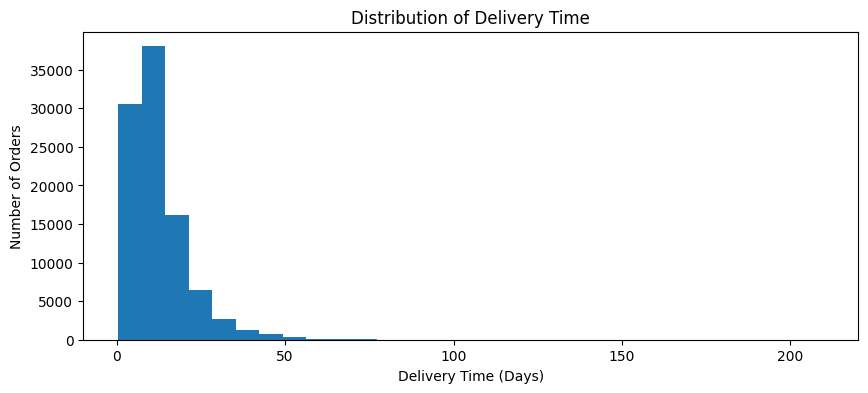

In [53]:
# Visualize delivery time distribution

plt.figure(figsize=(10, 4))

plt.hist(delivery_orders["delivery_time_days"], bins=30)

plt.title("Distribution of Delivery Time")
plt.xlabel("Delivery Time (Days)")
plt.ylabel("Number of Orders")

plt.show()

In [54]:
# Calculate late delivery rate

late_delivery_rate = delivery_orders["late_delivery"].mean() * 100

print("Late delivery rate:", late_delivery_rate)

Late delivery rate: 8.112366538820359


In [55]:
# Inspect orders with the longest delivery times

delivery_orders[["order_id", "order_purchase_timestamp", "order_delivered_customer_date", "order_estimated_delivery_date", "delivery_time_days", "late_delivery"]].sort_values("delivery_time_days", ascending=False).head(10)

,order_id,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date,delivery_time_days,late_delivery
19590,ca07593549f1816d26a572e06dc1eab6,2017-02-21 23:31:27,2017-09-19 14:36:39,2017-03-22,209.628611,True
55619,1b3190b2dfa9d789e1f14c05b647a14a,2018-02-23 14:57:35,2018-09-19 23:24:07,2018-03-15,208.351759,True
61610,440d0d17af552815d15a9e41abe49359,2017-03-07 23:59:51,2017-09-19 15:12:50,2017-04-07,195.634016,True
70307,2fb597c2f772eca01b1f5c561bf6cc7b,2017-03-08 18:09:02,2017-09-19 14:33:17,2017-04-17,194.850174,True
89130,285ab9426d6982034523a855f55a885e,2017-03-08 22:47:40,2017-09-19 14:00:04,2017-04-06,194.633611,True
38509,0f4519c5f1c541ddec9f21b3bddd533a,2017-03-09 13:26:57,2017-09-19 14:38:21,2017-04-11,194.049583,True
11399,47b40429ed8cce3aee9199792275433f,2018-01-03 09:44:01,2018-07-13 20:51:31,2018-01-19,191.463542,True
81401,2fe324febf907e3ea3f2aa9650869fa5,2017-03-13 20:17:10,2017-09-19 17:00:07,2017-04-05,189.863160,True
54480,2d7561026d542c8dbd8f0daeadf67a43,2017-03-15 11:24:27,2017-09-19 14:38:18,2017-04-13,188.134618,True
68769,c27815f7e3dd0b926b58552628481575,2017-03-15 23:23:17,2017-09-19 17:14:25,2017-04-10,187.743843,True
